In [21]:
save_fig_dir = "/home/emma/Dokumente/thesis/plotsnfigs"

## analysis of draft models

### imports and setup

In [2]:
model_dir = '/home/emma/Dokumente/thesis/Model_generation_curation/Draft_models/faa_models/'

In [1]:
model_dir_overwrite = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/mb1"

In [3]:
from cobra.io import read_sbml_model
import cobra 
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
loaded_model_dict = {}
for file in os.listdir(model_dir_overwrite):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir_overwrite, file))
    model_id = model.id
    loaded_model_dict[model_id] = model

### functions

In [12]:
import os
from cobra.io import read_sbml_model

def get_model_size_stats(model_dir_overwrite):
    """Load all SBML/XML models in model_dir and return comprehensive structural/balance counts."""
    counts = []
    for model_id, model in loaded_model_dict.items():
        # Track imbalances for the current model
        mass_unbalanced_count = 0
        charge_unbalanced_count = 0
        total_unbalanced_count = 0

        for rxn in model.reactions:
            # Exchange/demand/sink boundary reactions naturally don't balance out
            if rxn.boundary:
                continue
                
            balance_errors = rxn.check_mass_balance()
            if balance_errors:  # Dictionary is not empty means there is an imbalance
                total_unbalanced_count += 1
                
                # Check for charge imbalance specifically
                if 'charge' in balance_errors:
                    charge_unbalanced_count += 1
                    
                # Check for mass (elemental) imbalance specifically (anything other than 'charge')
                mass_elements = {k: v for k, v in balance_errors.items() if k != 'charge'}
                if mass_elements:
                    mass_unbalanced_count += 1
                    print(rxn)

        counts.append({
            'model': model,
            'reactions': len(model.reactions),
            'metabolites': len(model.metabolites),
            'unbalanced_total': total_unbalanced_count,
            'unbalanced_mass': mass_unbalanced_count,
            'unbalanced_charge': charge_unbalanced_count
        })

    return counts

In [13]:
def summarize_model_sizes(counts):
    if not counts:
        raise ValueError('No SBML/XML models were found in the provided model_dir.')

    total_models = len(counts)
    total_reactions = sum(item['reactions'] for item in counts)
    total_metabolites = sum(item['metabolites'] for item in counts)
    
    total_unbalanced = sum(item['unbalanced_total'] for item in counts)
    total_mass_unb = sum(item['unbalanced_mass'] for item in counts)
    total_charge_unb = sum(item['unbalanced_charge'] for item in counts)

    return {
        'models': total_models,
        'avg_reactions': total_reactions / total_models,
        'avg_metabolites': total_metabolites / total_models,
        'min_reactions': min(item['reactions'] for item in counts),
        'max_reactions': max(item['reactions'] for item in counts),
        'min_metabolites': min(item['metabolites'] for item in counts),
        'max_metabolites': max(item['metabolites'] for item in counts),
        'total_reactions': total_reactions,
        
        # New Imbalance Aggregations
        'total_unbalanced': total_unbalanced,
        'avg_unbalanced_per_model': total_unbalanced / total_models,
        'total_mass_unbalanced': total_mass_unb,
        'total_charge_unbalanced': total_charge_unb,
        'max_mass_unbalanced_single_model': max(item['unbalanced_mass'] for item in counts),
        'max_charge_unbalanced_single_model': max(item['unbalanced_charge'] for item in counts)
    }

In [14]:
def print_summary(summary):
    print(f"Models loaded: {summary['models']}")
    print(f"Average reactions: {summary['avg_reactions']:.2f}")
    print(f"Average metabolites: {summary['avg_metabolites']:.2f}")
    print(f"Reaction range: {summary['min_reactions']} - {summary['max_reactions']}")
    print(f"Metabolite range: {summary['min_metabolites']} - {summary['max_metabolites']}")
    print(f"Total reactions parsed: {summary['total_reactions']}")
    print("-" * 50)
    print(f"TOTAL Unbalanced Reactions: {summary['total_unbalanced']}")
    print(f"  └─ Mass Imbalances: {summary['total_mass_unbalanced']}")
    print(f"  └─ Charge Imbalances: {summary['total_charge_unbalanced']}")
    print(f"Average unbalanced per model: {summary['avg_unbalanced_per_model']:.2f}")
    print(f"Max mass unb. in a single model: {summary['max_mass_unbalanced_single_model']}")
    print(f"Max charge unb. in a single model: {summary['max_charge_unbalanced_single_model']}")

### Analysis

In [15]:
# average #metabolite and #reactions across models

#maybe this would also be interesting later to see differences between communities

summary = get_model_size_stats(model_dir_overwrite)

Growth: 0.000223 10fthf_c + 0.513689 ala__L_c + 0.000223 amet_c + 0.295792 arg__L_c + 0.241055 asn__L_c + 0.241055 asp__L_c + 54.124831 atp_c + 0.005205 ca2_c + 0.005205 cl_c + 0.000576 coa_c + 0.0001 cobalt2_c + 0.133508 ctp_c + 0.000709 cu2_c + 0.09158 cys__L_c + 0.026166 datp_c + 0.027017 dctp_c + 0.027017 dgtp_c + 0.026166 dttp_c + 0.000223 fad_c + 0.006715 fe2_c + 0.007808 fe3_c + 0.26316 gln__L_c + 0.26316 glu__L_c + 0.612638 gly_c + 0.215096 gtp_c + 48.601527 h2o_c + 0.094738 his__L_c + 0.290529 ile__L_c + 0.195193 k_c + 0.019456 kdo2lipid4_p + 0.450531 leu__L_c + 0.343161 lys__L_c + 0.153686 met__L_c + 0.008675 mg2_c + 0.000223 mlthf_c + 0.000691 mn2_c + 0.0001 mql8_c + 0.013894 murein5px4p_p + 0.001831 nad_c + 0.000447 nadp_c + 0.017868 pe160_c + 0.045946 pe160_p + 0.054154 pe161_c + 0.02106 pe161_p + 0.185265 phe__L_c + 0.000223 pheme_c + 0.221055 pro__L_c + 0.000223 pydx5p_c + 0.000223 ribflv_c + 0.215792 ser__L_c + 0.000223 sheme_c + 0.004338 so4_c + 0.000223 thf_c + 0.0002

In [16]:
summary_state = summarize_model_sizes(summary)

In [17]:
print_summary(summary_state)

Models loaded: 50
Average reactions: 2556.40
Average metabolites: 1675.60
Reaction range: 1969 - 3052
Metabolite range: 1270 - 1976
Total reactions parsed: 127820
--------------------------------------------------
TOTAL Unbalanced Reactions: 875
  └─ Mass Imbalances: 68
  └─ Charge Imbalances: 875
Average unbalanced per model: 17.50
Max mass unb. in a single model: 3
Max charge unb. in a single model: 36


In [1]:
# check draft models for IPPT 

gp_model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/ARCHIVE/Draft_models/Models"

In [7]:
rel_mod = []
for file in os.listdir(gp_model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(gp_model_dir, file))
    model_id = model.id
    if "IPPT" in model.reactions:
        print(model.id)
        rel_mod.append(model_id)

Adding exchange reaction EX_3ump_e with default bounds for boundary metabolite: 3ump_e.
Adding exchange reaction EX_6pgc_e with default bounds for boundary metabolite: 6pgc_e.
Adding exchange reaction EX_LalaDgluMdap_e with default bounds for boundary metabolite: LalaDgluMdap_e.
Adding exchange reaction EX_R_3httdca_e with default bounds for boundary metabolite: R_3httdca_e.
Adding exchange reaction EX_ac_e with default bounds for boundary metabolite: ac_e.
Adding exchange reaction EX_acgam1p_e with default bounds for boundary metabolite: acgam1p_e.
Adding exchange reaction EX_acnam_e with default bounds for boundary metabolite: acnam_e.
Adding exchange reaction EX_ala_leu_e with default bounds for boundary metabolite: ala_leu_e.
Adding exchange reaction EX_alaala_e with default bounds for boundary metabolite: alaala_e.
Adding exchange reaction EX_amp_e with default bounds for boundary metabolite: amp_e.
Adding exchange reaction EX_arg__L_e with default bounds for boundary metabolite: 

m_1056


Adding exchange reaction EX_6pgc_e with default bounds for boundary metabolite: 6pgc_e.
Adding exchange reaction EX_LalaDgluMdap_e with default bounds for boundary metabolite: LalaDgluMdap_e.
Adding exchange reaction EX_R_3httdca_e with default bounds for boundary metabolite: R_3httdca_e.
Adding exchange reaction EX_ac_e with default bounds for boundary metabolite: ac_e.
Adding exchange reaction EX_acald_e with default bounds for boundary metabolite: acald_e.
Adding exchange reaction EX_acgam1p_e with default bounds for boundary metabolite: acgam1p_e.
Adding exchange reaction EX_akg_e with default bounds for boundary metabolite: akg_e.
Adding exchange reaction EX_ala_L_thr__L_e with default bounds for boundary metabolite: ala_L_thr__L_e.
Adding exchange reaction EX_alaala_e with default bounds for boundary metabolite: alaala_e.
Adding exchange reaction EX_amp_e with default bounds for boundary metabolite: amp_e.
Adding exchange reaction EX_arg__L_e with default bounds for boundary meta

m_892


Adding exchange reaction EX_2obut_e with default bounds for boundary metabolite: 2obut_e.
Adding exchange reaction EX_6pgc_e with default bounds for boundary metabolite: 6pgc_e.
Adding exchange reaction EX_LalaDgluMdap_e with default bounds for boundary metabolite: LalaDgluMdap_e.
Adding exchange reaction EX_R_3httdca_e with default bounds for boundary metabolite: R_3httdca_e.
Adding exchange reaction EX_ac_e with default bounds for boundary metabolite: ac_e.
Adding exchange reaction EX_acmana_e with default bounds for boundary metabolite: acmana_e.
Adding exchange reaction EX_acnam_e with default bounds for boundary metabolite: acnam_e.
Adding exchange reaction EX_ala__L_e with default bounds for boundary metabolite: ala__L_e.
Adding exchange reaction EX_ala_leu_e with default bounds for boundary metabolite: ala_leu_e.
Adding exchange reaction EX_alaala_e with default bounds for boundary metabolite: alaala_e.
Adding exchange reaction EX_amp_e with default bounds for boundary metabolit

# Taxonomic distribution

In [12]:
df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")

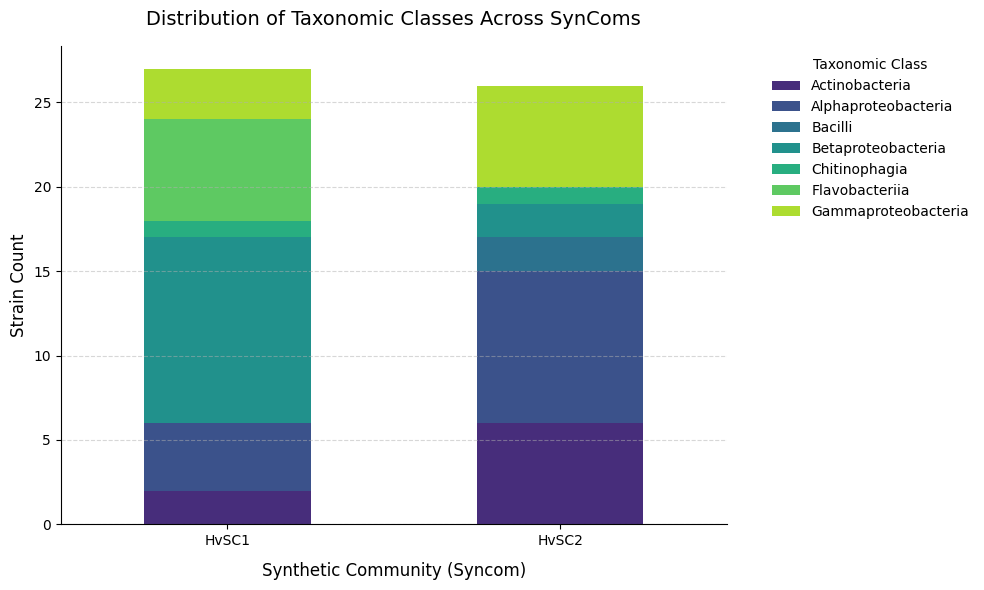

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

syncom_mapping = {"Both": ["HvSC1", "HvSC2"]}

df["Syncom"] = df["Syncom"].apply(lambda x: syncom_mapping.get(x, x))
df = df.explode("Syncom")
counts_df = df.groupby(["Syncom", "Class"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", n_colors=len(counts_df.columns))

# Capture the axes object (ax) to manipulate borders
ax = plt.gca()
counts_df.plot(kind="bar", stacked=True, color=colors, ax=ax)

# 4. Customize labels and appearance
plt.title("Distribution of Taxonomic Classes Across SynComs", fontsize=14, pad=15)
plt.xlabel("Synthetic Community (Syncom)", fontsize=12, labelpad=10)
plt.ylabel("Strain Count", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)



# Option B: Alternatively, if you want to keep just the bottom X-axis baseline, use Seaborn:
sns.despine(top=True, right=True, left=False, bottom=False)
# ------------------------------------

# Place legend outside the plot box so it doesn't cover data points
plt.legend(title="Taxonomic Class", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(save_fig_dir, "taxonomy_distr.svg"))
plt.show()